# ML Methods on XM Data
The general idea of this notebook is to see if we can use some machine learning or -vision methods to better understand and analyse the relative data, and understand what columns we want in our final big table

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import copy

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

import pygmmis
import sys
# ESA pc
sys.path.append('/home/rkievit/masterproject/masterproject/src')
# Home PC
sys.path.append('F:\\OneDrive - Telecom Business Transformers BV\\School\\Uni\\MSc Year 2\\Master Research Project\\Project\\masterproject\\src')
# Uni PC
sys.path.append('/net/student36/data2/kievit/Master Project/masterproject/src')
# Laptop
sys.path.append('/home/rens/projects/mp_dir/masterproject/src/')

from plotting_functions import set_styles
#from make_big_table import get_delta_logG
set_styles()


fpath = '../../../figures/'

In [2]:
hdul = fits.open('../../results/all_neighbours_ml_data_final.fits')
tab = hdul[1].data
# GET FIELD NAMES
names = []
for i in range(len(tab[0])):
    names.append(hdul[1].header[f'TTYPE{i+1}'])
print(names)

['hip_id', 'gaia source_id', 'method', 'G_Gpred', 'Hp_mag', 'G_mag', 'Hip_BV', 'Gaia_BpRp', 'D', 'distance', 'delta_pm_alpha', 'delta_pm_dec', 'delta_pm_tot', 'delta_pm_angle', 'delta_plx']


The first two columns are only Hipparcos and Gaia identifiers, they do not contain any specific information about the star. (Possible information we could extract though is flag something when all three selection methods return the same result)

## Table preprocessing
Remove the ID slots (but make sure indexing stays constant), take some parameters into log-space to ensure they are all on the same scale. Parameters to take into log space:
- D
- distance
- delta_pm_alpha
- delta_pm_dec
- delta_pm_tot

In [5]:
 # easier to work with np arrays. Use names for indexing
print(names)
dnames = list( names[i] for i in [3, 8, 12, 13, 14] )

to_logspace = []#['D', 'distance', 'delta_pm_alpha', 'delta_pm_dec']#, 'delta_pm_tot']
to_abslog = []#Q['D', 'delta_pm_tot', 'delta_plx']
print(dnames)
data = np.zeros((len(tab), len(dnames)))

['hip_id', 'gaia source_id', 'method', 'G_Gpred', 'Hp_mag', 'G_mag', 'Hip_BV', 'Gaia_BpRp', 'D', 'distance', 'delta_pm_alpha', 'delta_pm_dec', 'delta_pm_tot', 'delta_pm_angle', 'delta_plx']
['G_Gpred', 'D', 'delta_pm_tot', 'delta_pm_angle', 'delta_plx']


In [6]:
# Fill up processed data table
for i,name in enumerate(dnames):
    col = tab[name]
    if name in to_logspace:
        pass#col = np.log10(col)
    if name in to_abslog:
        col[np.abs(col) < 1e-10] = 0
        col[col>0] = np.log10(col[col>0])
        col[col<0] = - np.log10(-col[col<0])
    if name == 'Gaia_BpRp': # 15 Gaia objects have BpRp = 1e+20, really they don't have a value in the Gaia Archive. For now set these to 0
        col[col>1e15] = 0
    if name == 'delta_plx':
        col[col>1e15] = 0
    if name == 'delta_pm_angle':
        col[np.isnan(col)] = 0
    data[:,i] = col

In [57]:
max(data[:,1])

60590.52932615587

In [17]:
data[np.where(data == 0)[0], 2] = 0 # set all proper motions with angles that were NaN to zero

In [16]:
print(np.where(data == 0)[0])

[    25     25     37 ... 128050 128066 128066]


## Machine Vision
Let's start with some simple visualization methods

### PCA

In [ ]:
pca_obj = PCA(n_components=0.99)
data_pca = np.ascontiguousarray(pca_obj.fit_transform(data))

In [ ]:
print(f"""PCA Done:
Table Size
    - Num Samples   : {pca_obj.n_samples_}
    - Num Features  : {pca_obj.n_features_}
Number of Dimensions: {pca_obj.n_components_}
Explained Variance  : {pca_obj.explained_variance_}
    - Ratios        : {pca_obj.explained_variance_ratio_}""")

In [ ]:
# Plotting
fig, axs = plt.subplots(1,pca_obj.n_components_,figsize=(5*pca_obj.n_components_, 5), sharey=True)
#plt.subplots_adjust(vspace=0.01)
for i in range(pca_obj.n_components_):
    ax = axs[i]
    ax.hist(data_pca[:,i], bins=50, density=True)
    ax.set_xlabel(f'PCA Dim {i}')
axs[0].set_ylabel('Normalized Density')
plt.show()

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(6,6))
#ax.scatter(data_pca[:,0], data_pca[:,1], s=2)
ax.hexbin(data_pca[:,0], data_pca[:,6], mincnt=1, cmap='viridis')
ax.set_xlabel("PCA DIM0")
ax.set_ylabel("PCA DIM1")
plt.show()

### t-SNE

In [ ]:
tsne_obj = TSNE()
data_tsne = tsne_obj.fit_transform(data)

In [ ]:
print(data_tsne)

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(17,8))
ax[0].scatter(data_tsne[:,0], data_tsne[:,1],s=1,c=labels+1, vmin=1, vmax=10,cmap='jet')
#ax[1].scatter(data_tsne[:,0], data_tsne[:,1],s=1,c=tab['G_Gpred'],cmap='jet')
#ax.set_xscale('log')
#ax.set_yscale('log')

## Machine Learning

### PyGMMis

In [ ]:
num_clusters = 50
gmm = pygmmis.GMM(K=num_clusters, D=data.shape[1])
LogL, U = pygmmis.fit(gmm, data[::3], cutoff=3)

In [ ]:
print(gmm.amp)

In [ ]:
sum = 0

for u in U:

    fig, axs = plt.subplots(1,2,figsize=(10,5))
    axs[0].scatter(data_tsne[:,0][::3][u], data_tsne[:,1][::3][u],s=1)
    axs[1].scatter(tab['Hip_BV'][::3][u], tab['G_Gpred'][::3][u], s=1)
    axs[1].invert_yaxis()


In [ ]:
all_in_u = np.array([])
for u in U:
    all_in_u = np.append(all_in_u, u)
uniques = np.unique(all_in_u)
not_in_u = []#copy.deepcopy(tab['hip_id'][::3])
for i in range(len(tab['hip_id'][::3])):
    if tab['hip_id'][::3][i] not in uniques:
        not_in_u.append(i)

In [ ]:
print(len(uniques))
print(not_in_u)

### Normal Mixture Model
Try and compute the Bayesian Information Criterion

In [ ]:
kmeans_obj = GaussianMixture(n_components=8)
kmeans_obj = kmeans_obj.fit(data)

In [ ]:
labels = kmeans_obj.predict(data)

In [ ]:
print(names)

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(9,5))
spread = ax.scatter(tab['Hip_BV'], tab['G_Gpred'], c=labels, cmap='Set1', s=1)
plt.colorbar(spread)
ax.invert_yaxis()
plt.show()

In [ ]:
len(tab['G_Gpred'][labels==7])

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(7,5))
ax.scatter(np.log10(tab['D']), np.log10(tab['delta_pm_tot']), c=labels, cmap='Set1', s=1)
plt.show()

In [ ]:
plt.scatter(tab['G_Gpred'], np.log10(tab['D']), c=labels, s=1, cmap='Set1')

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(6,6))
ax.scatter(tab['Hip_BV'], tab['Gaia_BpRp'], c=labels, cmap='Set1', s=1)

In [ ]:
#bv_giants = tab['Hip_BV'][labels==5]
u, c = np.unique(tab['Hip_BV'][tab['Gaia_BpRp'] > 4], return_counts=True)
degen = u[c>2e2]
print(c[c>2e2])
degen[degen>1]

In [ ]:
print(dnames)
np.set_printoptions(threshold=sys.maxsize)
print(data[labels==3][::3])

In [ ]:
scores = np.zeros(20)
for i in range(1,21):
    kmeans_obj = KMeans(n_clusters=i, n_init=5)
    kmeans_obj.fit(data)
    scores[i-1] = kmeans_obj.score(data)

In [ ]:
plt.scatter(np.arange(20), scores)

## Gaussian Mixture Model

In [35]:
# Find the BIC of the data
max_N = 20
num_iter = 5
BIC_table = np.zeros((max_N, num_iter))

for i in range(0,max_N):
    print(f'Calculating BIC for {i+1} components')
    for j in range(num_iter):
        print(f'iteration {j+1}', end='\r')
        gmm_bic = GaussianMixture(n_components=i+1)
        gmm_bic.fit(data)
        BIC_table[i][j] = gmm_bic.bic(data)
        #print(BIC_table)

Calculating BIC for 1 components
Calculating BIC for 2 components
Calculating BIC for 3 components
Calculating BIC for 4 components
Calculating BIC for 5 components
Calculating BIC for 6 components
Calculating BIC for 7 components
Calculating BIC for 8 components
Calculating BIC for 9 components
Calculating BIC for 10 components
Calculating BIC for 11 components
Calculating BIC for 12 components
Calculating BIC for 13 components
Calculating BIC for 14 components
Calculating BIC for 15 components
Calculating BIC for 16 components
Calculating BIC for 17 components
Calculating BIC for 18 components
Calculating BIC for 19 components
Calculating BIC for 20 components


In [36]:
BIC_table

array([[    6533.94505772,     6533.94505772,     6533.94505772,
            6533.94505772,     6533.94505772],
       [-1997205.85641819, -1997205.85641819, -1997205.85641819,
        -1997205.85641819, -1997205.85641819],
       [-2614383.43352344, -2614385.19243615, -2614385.19243615,
        -2614383.09253476, -2614383.09253476],
       [-3087800.6849845 , -3087803.44272976, -3087800.46741246,
        -3087809.70125105, -2975674.42237984],
       [-3259450.69925367, -3193657.11264903, -3259472.05931891,
        -3193657.11264903, -2746514.77963265],
       [-3300256.28360924, -3300294.43749065, -3300288.8719082 ,
        -3300256.44039903, -3299537.47167254],
       [-3314633.18746099, -3273240.99479704, -3352405.98453887,
        -3352154.28331878, -3273153.69079551],
       [-3448700.92568454, -3410843.77697988, -3448806.00007431,
        -3325852.60211675, -3328679.25799776],
       [-3403386.41709534, -3429371.67525158, -3429372.36684612,
        -3404578.07999504, -3366495.438

No handles with labels found to put in legend.


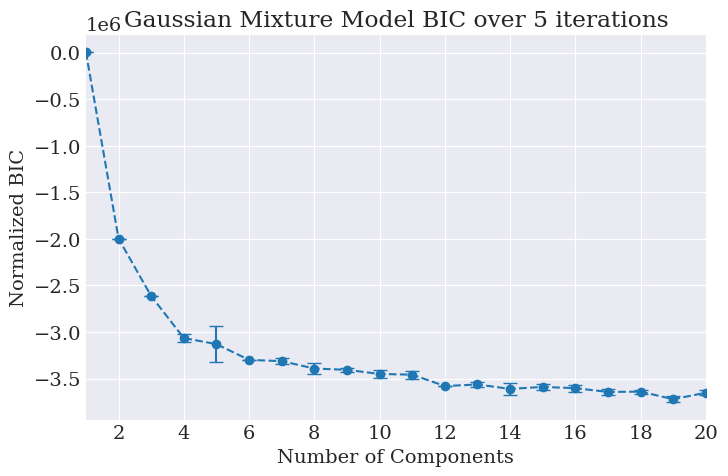

In [38]:
fig, ax = plt.subplots(1,1,figsize=(8,5))
N = np.arange(BIC_table.shape[0]) + 1
mean = np.mean(BIC_table, axis=1)
std = np.std(BIC_table, axis=1)

#ax.plot(N, mean/np.max(mean), c='C0', marker='o', ls='--', label='Mean')
#ax.fill_between(N, (mean-std)/np.max(mean), (mean+std)/np.max(mean), color='C0', alpha=0.4, label=r'$1\sigma$ CI')
#ax.errorbar(N, mean/np.max(mean), yerr=std/np.max(mean), ls='--', marker='o', capsize=5)
ax.errorbar(N, mean, yerr=std, ls='--', marker='o', capsize=5)

ax.set_xticks(N[1::2])
ax.set_xlim(1, max(N))
ax.set_ylabel('Normalized BIC')
ax.set_xlabel('Number of Components')
ax.set_title('Gaussian Mixture Model BIC over 5 iterations')

plt.legend()
#plt.savefig(fpath+'GMM_BIC_full_table_signlog.png', bbox_inches='tight')
plt.show()

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(8,5))

rel_improv = (mean[1:] - mean[:-1])/mean[:-1]
ax.errorbar(N[1:], rel_improv, yerr=std[1:]/np.max(mean),  ls='--', marker='o', capsize=5)

ax.set_xticks(N[1::2])
ax.set_xlim(1, max(N))
ax.set_ylabel('Relative Improvement')
ax.set_xlabel('Number of Components')
ax.set_title('Gaussian Mixture Model BIC over 3 iterations')

In [26]:
gmm = GaussianMixture(n_components=8, random_state=42)
gmm.fit(data)

GaussianMixture(n_components=8, random_state=42)

In [27]:
print(gmm.random_state)

42


In [28]:
labels = gmm.predict(data)

In [35]:
print(dnames)
#for i in range(gmm.n_components):
#    print()
#    print('Component ', i, f'(weight = {gmm.weights_[i]:.2E})')
#    print('Means, ', gmm.means_[i])
#    print('Sigmas,', np.diag(gmm.covariances_[i]))
tab_txt = "Component & Weight "
for name in dnames:
    tab_txt += f" & {name}"
tab_txt += ' \\\\\n\hline\n'
for i in range(gmm.n_components):
    tab_txt += f'{i+1} & {gmm.weights_[i]:.2E}'
    for j in range(len(dnames)):
        tab_txt += f' & {gmm.means_[i][j]:.2E} $\pm$ {np.sqrt(gmm.covariances_[i][j][j]):.2E}'
    tab_txt += ' \\\\\n'
print(tab_txt)

['G_Gpred', 'D', 'delta_pm_tot', 'delta_pm_angle', 'delta_plx']
Component & Weight  & G_Gpred & D & delta_pm_tot & delta_pm_angle & delta_plx \\
\hline
1 & 3.48E-01 & 2.79E-04 $\pm$ 1.77E-02 & 1.92E+00 $\pm$ 1.23E+00 & -1.60E-02 $\pm$ 9.37E-01 & 1.64E-02 $\pm$ 1.47E-02 & -5.24E-02 $\pm$ 1.02E+00 \\
2 & 5.90E-02 & 2.34E+00 $\pm$ 2.03E+00 & 2.00E+03 $\pm$ 2.18E+03 & -1.24E-01 $\pm$ 3.53E+00 & 7.17E-02 $\pm$ 6.80E-02 & -3.99E-02 $\pm$ 1.39E+00 \\
3 & 9.29E-03 & 1.56E+00 $\pm$ 2.35E+00 & 2.05E+03 $\pm$ 4.31E+03 & -4.75E+01 $\pm$ 1.23E+02 & 8.07E-01 $\pm$ 8.77E-01 & -4.98E+00 $\pm$ 2.36E+01 \\
4 & 1.27E-01 & -2.32E-02 $\pm$ 3.39E-01 & 3.73E+00 $\pm$ 3.86E+00 & -1.69E-01 $\pm$ 2.03E+00 & 2.37E-01 $\pm$ 3.32E-01 & -8.24E-02 $\pm$ 2.33E+00 \\
5 & 2.59E-01 & -4.51E-03 $\pm$ 3.48E-02 & 5.23E+00 $\pm$ 4.47E+00 & -3.60E-02 $\pm$ 1.06E+00 & 6.79E-02 $\pm$ 5.65E-02 & -6.44E-02 $\pm$ 1.13E+00 \\
6 & 2.48E-02 & 1.43E+00 $\pm$ 1.98E+00 & 1.12E+03 $\pm$ 1.68E+03 & 9.85E-11 $\pm$ 1.00E-03 & 4.05E-10 $\pm

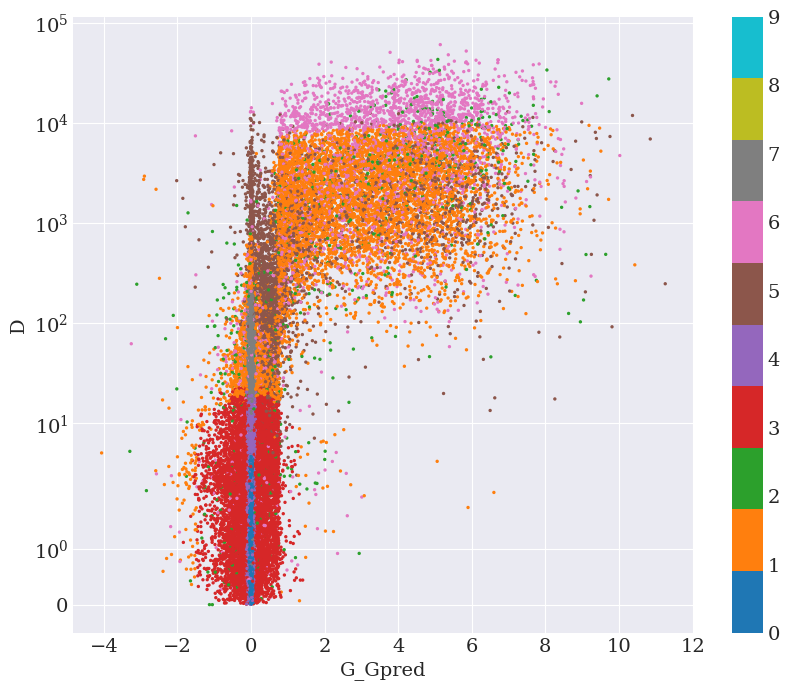

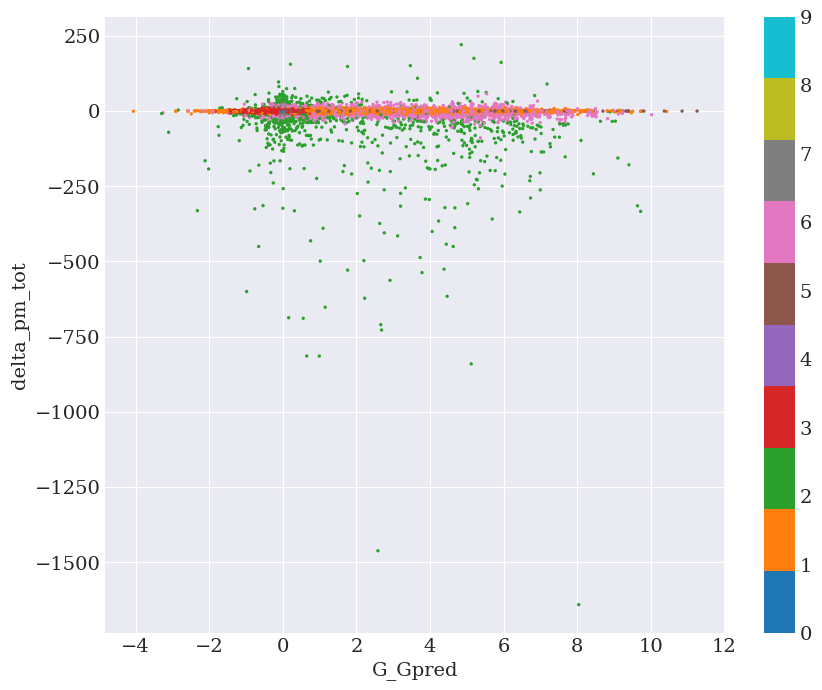

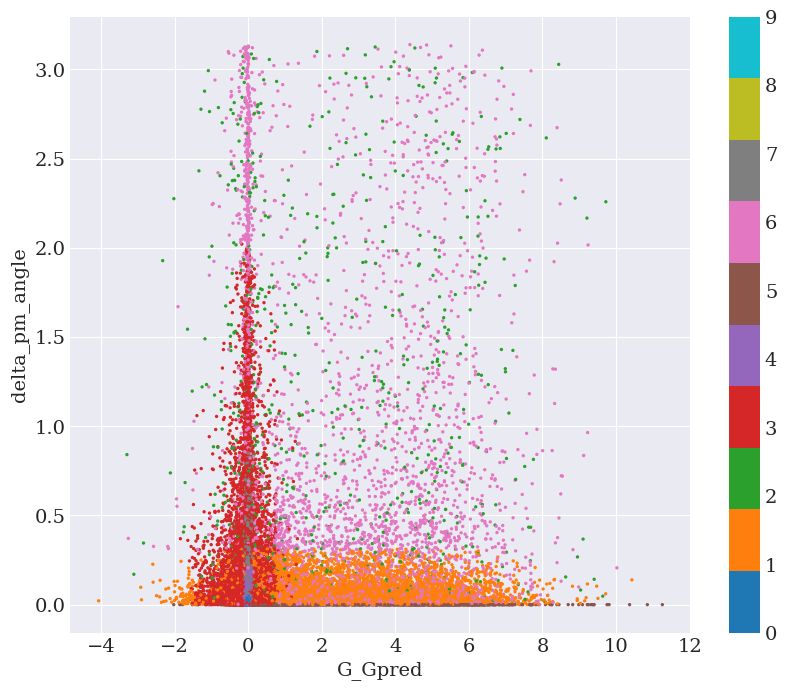

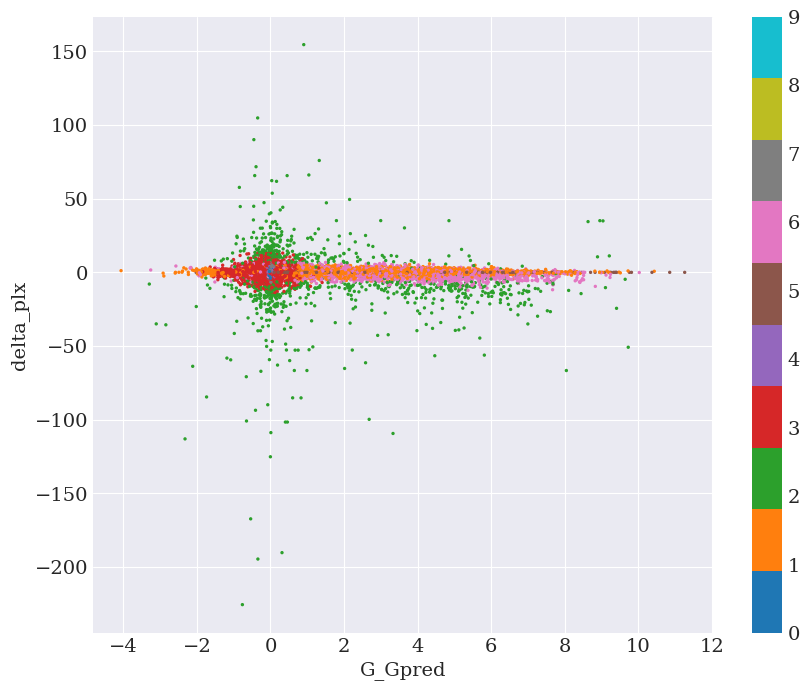

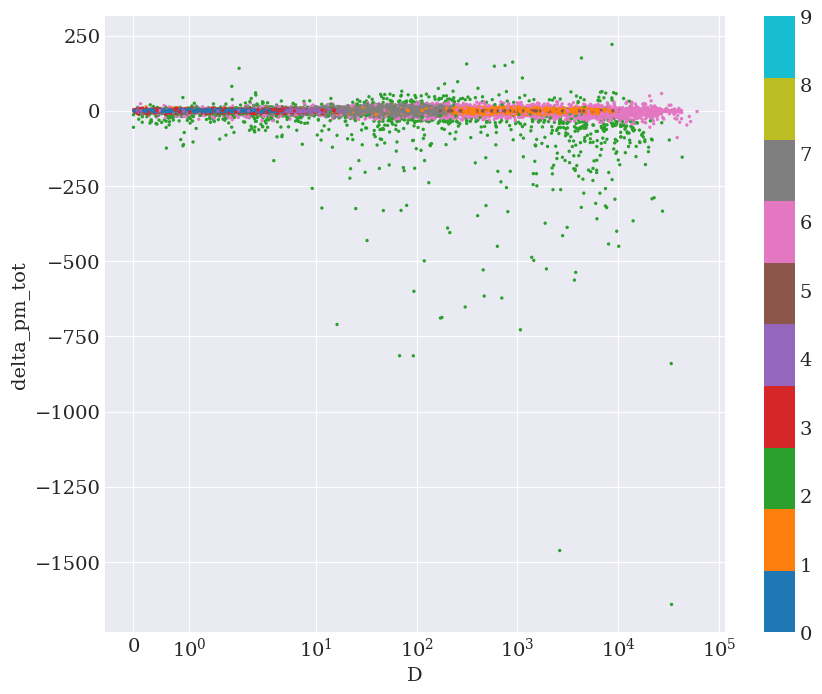

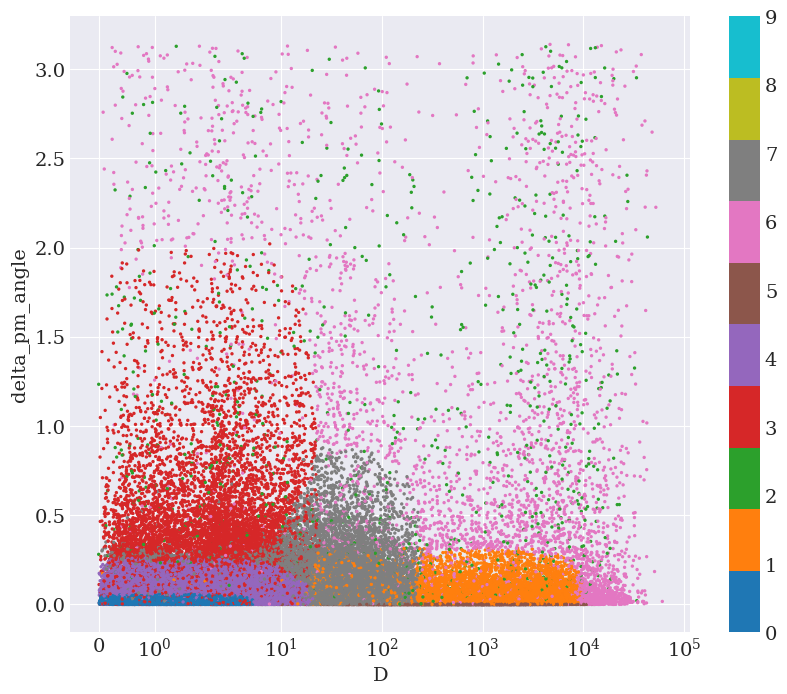

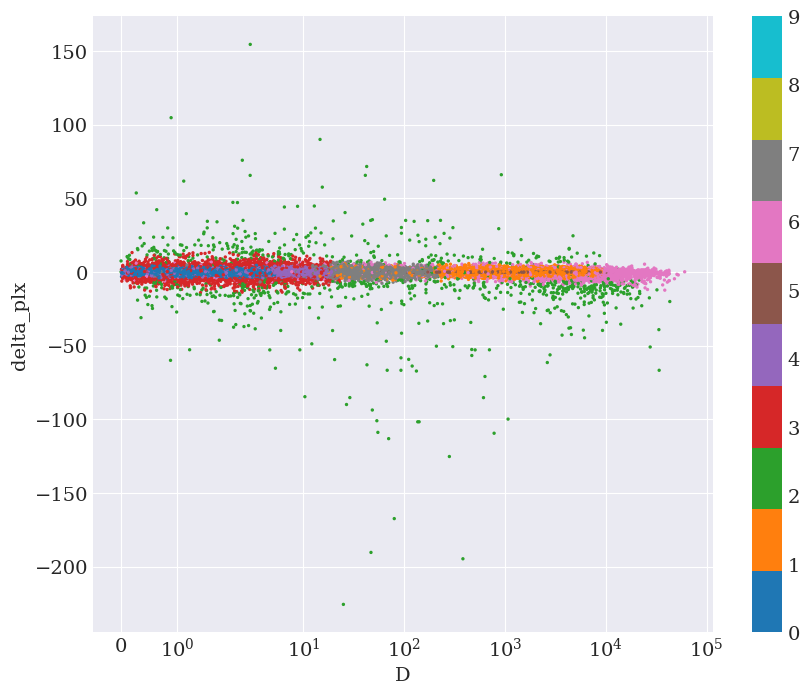

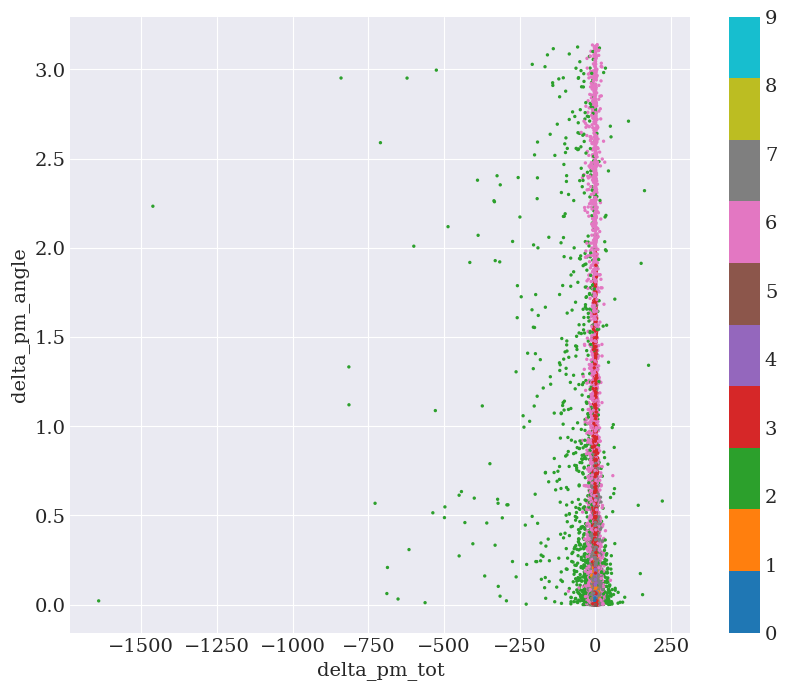

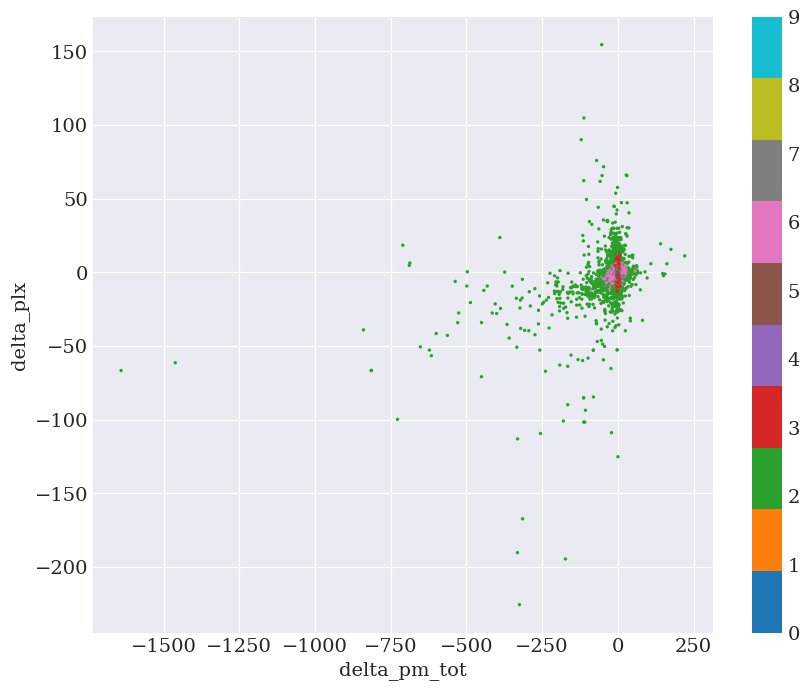

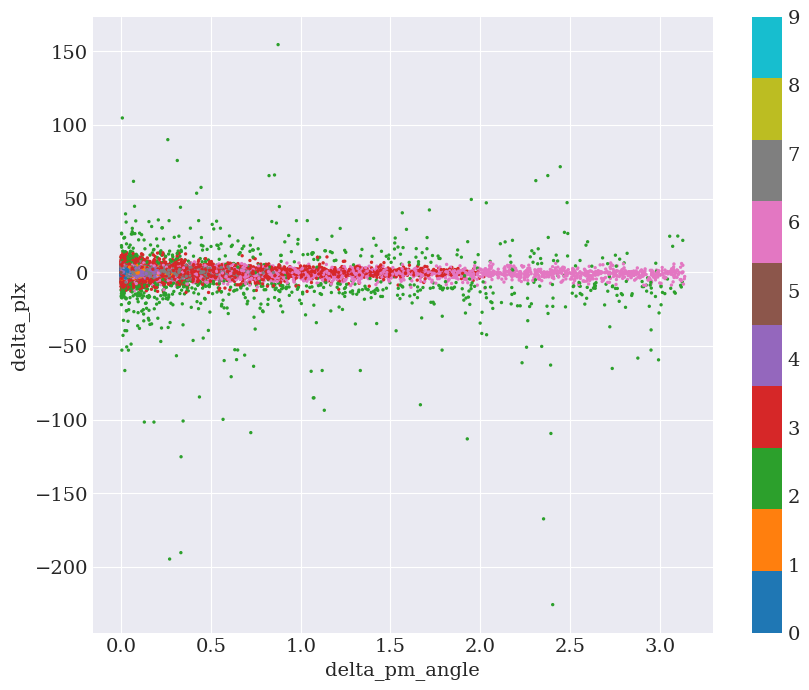

In [30]:
plot_log = ['D']#['D', 'delta_pm_tot', 'delta_plx']
for i in range(len(dnames)):
    for j in range(i+1, len(dnames)):
        fig, ax = plt.subplots(1,1,figsize=(10,8))
        xname= dnames[i]
        yname = dnames[j]
        #spread = ax.scatter(tab[xname], tab[yname], c=labels, s=2, cmap='tab10')
                  
        spread = ax.scatter(data[:,i], data[:,j], s=2, c=labels,cmap='tab10', vmin=0, vmax=9)
        if xname in plot_log:
            ax.set_xscale('symlog')
        if yname in plot_log:
            ax.set_yscale('symlog')
        ax.set_xlabel(xname)
        ax.set_ylabel(yname)
        plt.colorbar(spread)
        plt.show()

In [34]:
for covar in gmm.covariances_:
    corr = np.zeros_like(covar)
    for i in range(covar.shape[0]):
        for j in range(covar.shape[0]):
            if i == j:
                corr[i][j] = 1.
            else:
                corr[i][j] = covar[i][j] / np.sqrt((covar[i][i]**2) * (covar[j][j]**2))
    print(covar)
    #print(corr)

[[ 3.12499882e-04  1.08391320e-03  6.00119967e-05  2.65523797e-05
  -1.08240581e-04]
 [ 1.08391320e-03  1.52280237e+00  6.77564271e-03 -8.56315389e-04
  -1.16333393e-02]
 [ 6.00119967e-05  6.77564271e-03  8.78423890e-01  2.30405820e-05
   9.87398276e-03]
 [ 2.65523797e-05 -8.56315389e-04  2.30405820e-05  2.15134623e-04
   1.07167003e-06]
 [-1.08240581e-04 -1.16333393e-02  9.87398276e-03  1.07167003e-06
   1.05017944e+00]]
[[ 4.12105951e+00  1.95305238e+03  2.00899520e-02 -2.78090061e-03
  -3.70651040e-02]
 [ 1.95305238e+03  4.74360484e+06  3.71772232e+01 -1.12747932e+01
  -2.89452523e+01]
 [ 2.00899520e-02  3.71772232e+01  1.24894334e+01 -2.32635553e-03
   6.84363247e-02]
 [-2.78090061e-03 -1.12747932e+01 -2.32635553e-03  4.62319603e-03
  -8.32283002e-04]
 [-3.70651040e-02 -2.89452523e+01  6.84363247e-02 -8.32283002e-04
   1.91953616e+00]]
[[ 5.50277729e+00  6.34032996e+03 -7.25319652e+01  4.39778552e-01
  -5.68292288e+00]
 [ 6.34032996e+03  1.86113300e+07 -1.46329344e+05  6.87489592e+

In [ ]:
len(data[:,3][data[:,3] < 1e-10])

log G seems a little bit uninformative, and quite dominant. How do the two log g values compare?

In [ ]:
# test on a 'random' crossmatch
xm = np.load('../../results/final_crossmatch+PMC+EIB_10as__best_neighbour_likeliest_position.npy')
logg_gaia, logg_hipp = get_delta_logG(xm)

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(10,8))
density = ax.hexbin(logg_gaia.T, logg_hipp, mincnt=1, cmap='jet', bins='log')
plt.colorbar(density)
ax.set_xlabel('Gaia')
ax.set_ylabel('Hipp')

# Add in TDSC

In [ ]:
names

In [ ]:
hipid = 25085

idxs = np.where(tab['Hip_ID'] == hipid)[0]
for idx in idxs:
    d = tab[idx]
    print(d[1])
    #print(tab[idx][3:])
print(d)

In [ ]:
all_neighbours = np.load('../../results/final_crossmatch+PMC+EIB_10as_all_neighbours.npy')

In [ ]:
u, c = np.unique(all_neighbours[:,0], return_counts=True)
print(np.max(c))

In [ ]:
all_neighbours[all_neighbours[:,0] == hipid]

In [ ]:
rpath = '../../results/'
pos_xm = np.load(rpath+'final_crossmatch+PMC+EIB_10as__best_neighbour_likeliest_position.npy')
mag_xm = np.load(rpath+'final_crossmatch+PMC+EIB_10as__best_neighbour_likeliest_magnitude.npy')
nea_xm = np.load(rpath+'final_crossmatch+PMC+EIB_10as_best_neighbour_nearest.npy')

xm_tabs = [pos_xm, mag_xm, nea_xm]

In [ ]:
for xm in xm_tabs:
    print(xm[xm[:,0] == hipid])

In [ ]:
from data_queries import gaia_login, launch_job, get_data
query = 'select hip from gaiadr3.tycho2tdsc_merge where hip is not null'
job = launch_job(query)
data = get_data(job)

In [ ]:
u, c = np.unique(data['hip'], return_counts=True)
doubles = u[c>1]

In [ ]:
print(len(doubles))

In [ ]:
no_dubs = 0
for hip in doubles:
    if all_neighbours[all_neighbours[:,0] == hip].shape[0] == 1:
        print(hip)
        no_dubs += 1
print(no_dubs)

In [93]:
gmm = GaussianMixture(n_components=5)
gmm.fit(data)

GaussianMixture(n_components=5)

In [94]:
labels = gmm.predict(data)

In [95]:
print(dnames)
#for i in range(gmm.n_components):
#    print()
#    print('Component ', i, f'(weight = {gmm.weights_[i]:.2E})')
#    print('Means, ', gmm.means_[i])
#    print('Sigmas,', np.diag(gmm.covariances_[i]))
tab_txt = "Component & Weight "
for name in dnames:
    tab_txt += f" & {name}"
tab_txt += ' \\\\\n\hline\n'
for i in range(gmm.n_components):
    tab_txt += f'{i+1} & {gmm.weights_[i]:.2E}'
    for j in range(len(dnames)):
        tab_txt += f' & {gmm.means_[i][j]:.2E} $\pm$ {gmm.covariances_[i][j][j]:.2E}'
    tab_txt += ' \\\\\n'
print(tab_txt)

['G_Gpred', 'D', 'delta_pm_tot', 'delta_pm_angle', 'delta_plx']
Component & Weight  & G_Gpred & D & delta_pm_tot & delta_pm_angle & delta_plx \\
\hline
1 & 5.12E-01 & 5.11E-04 $\pm$ 3.16E-04 & 3.40E-01 $\pm$ 2.73E-01 & -1.46E-02 $\pm$ 8.71E-01 & 2.33E-02 $\pm$ 4.93E-04 & -7.97E-02 $\pm$ 9.82E-01 \\
2 & 4.33E-02 & 1.39E+00 $\pm$ 4.93E+00 & 1.80E+00 $\pm$ 2.13E+00 & -1.16E+01 $\pm$ 3.67E+03 & 9.48E-01 $\pm$ 6.65E-01 & -1.52E+00 $\pm$ 1.32E+02 \\
3 & 2.50E-02 & 1.44E+00 $\pm$ 3.93E+00 & 2.61E+00 $\pm$ 4.98E-01 & -5.70E+01 $\pm$ 4.93E+03 & 1.69E-06 $\pm$ 1.00E-06 & -4.01E-07 $\pm$ 1.00E-06 \\
4 & 2.85E-01 & -8.69E-03 $\pm$ 2.61E-03 & 7.14E-01 $\pm$ 5.28E-01 & -7.12E-02 $\pm$ 4.49E+00 & 1.60E-01 $\pm$ 2.71E-02 & -8.96E-02 $\pm$ 2.34E+00 \\
5 & 1.35E-01 & 1.22E+00 $\pm$ 3.71E+00 & 1.77E+00 $\pm$ 2.05E+00 & -1.61E-01 $\pm$ 1.63E+01 & 6.66E-02 $\pm$ 4.99E-03 & -6.65E-02 $\pm$ 2.43E+00 \\



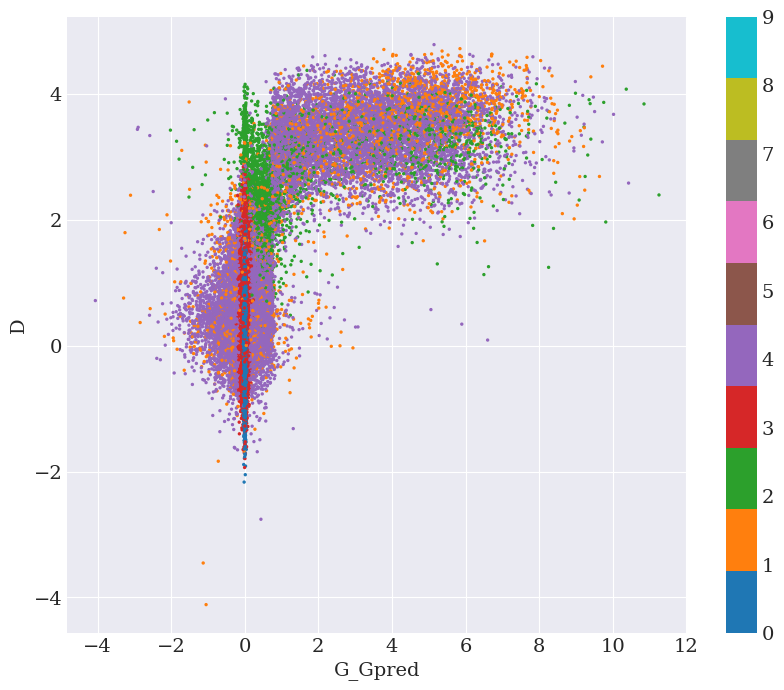

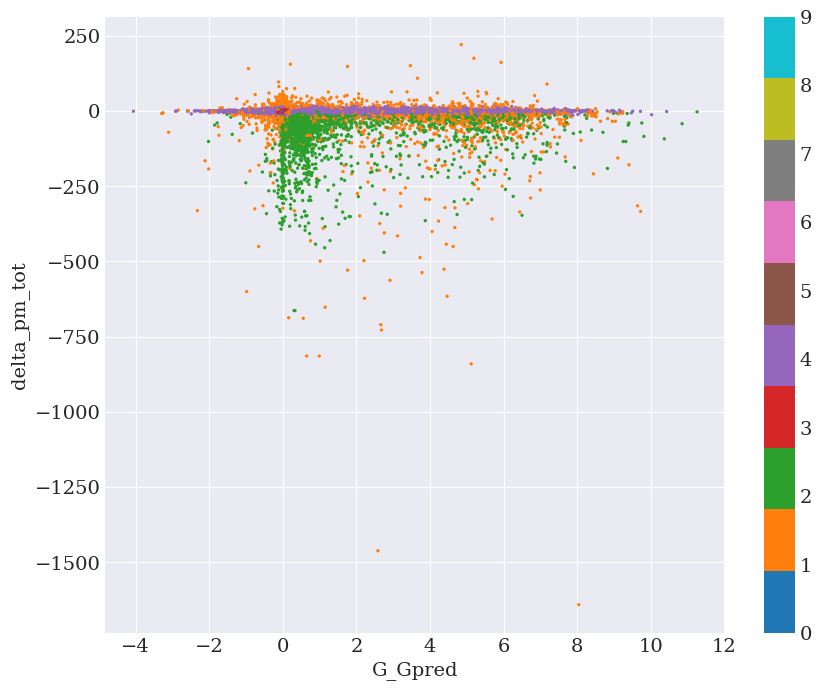

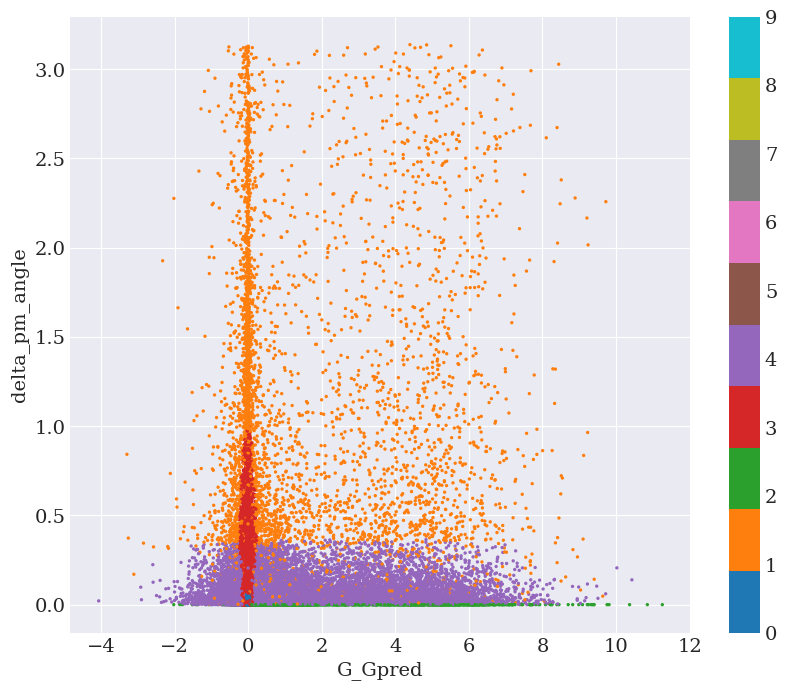

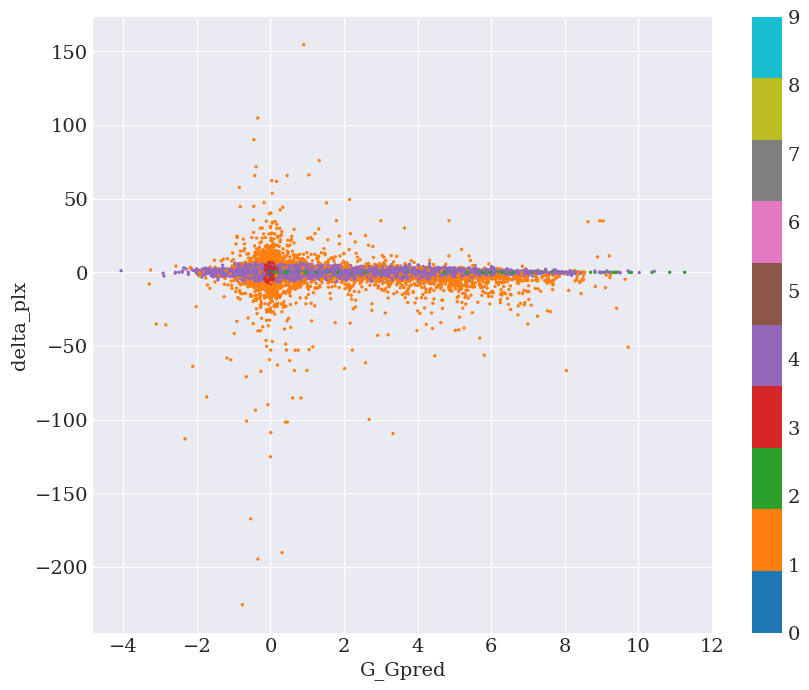

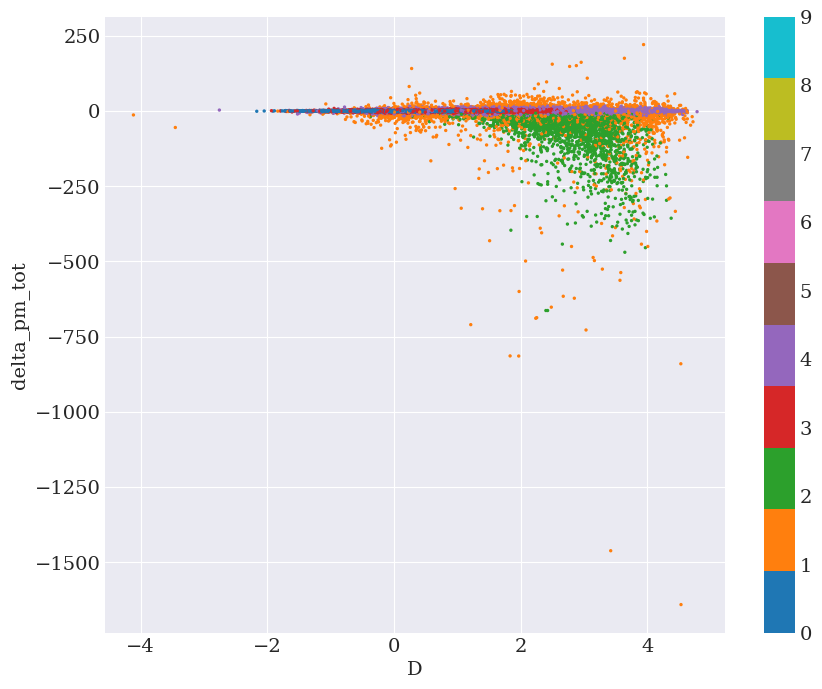

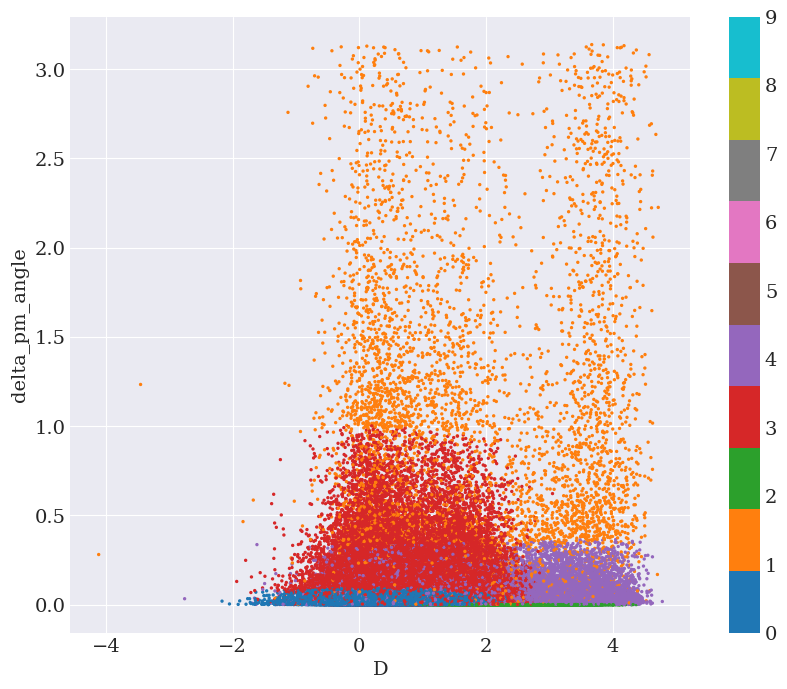

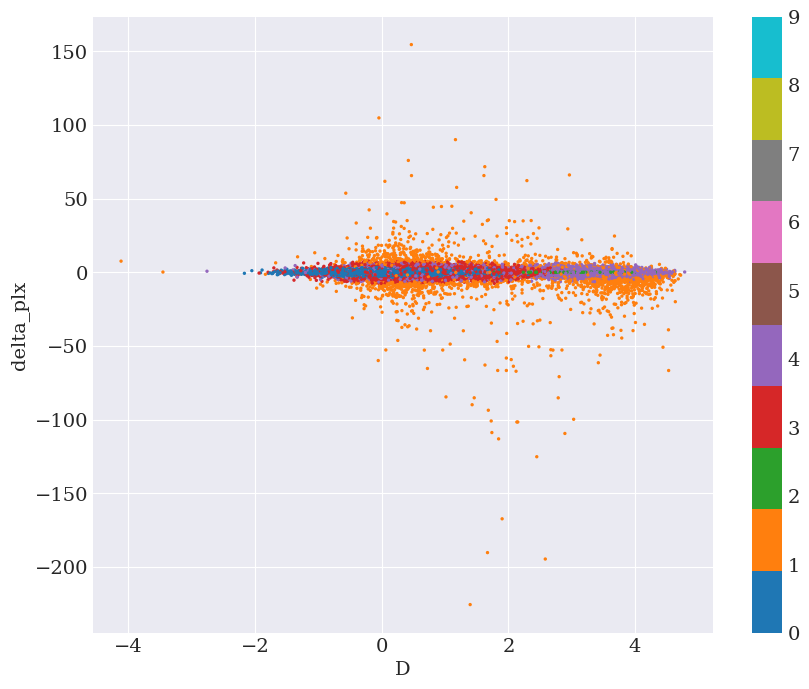

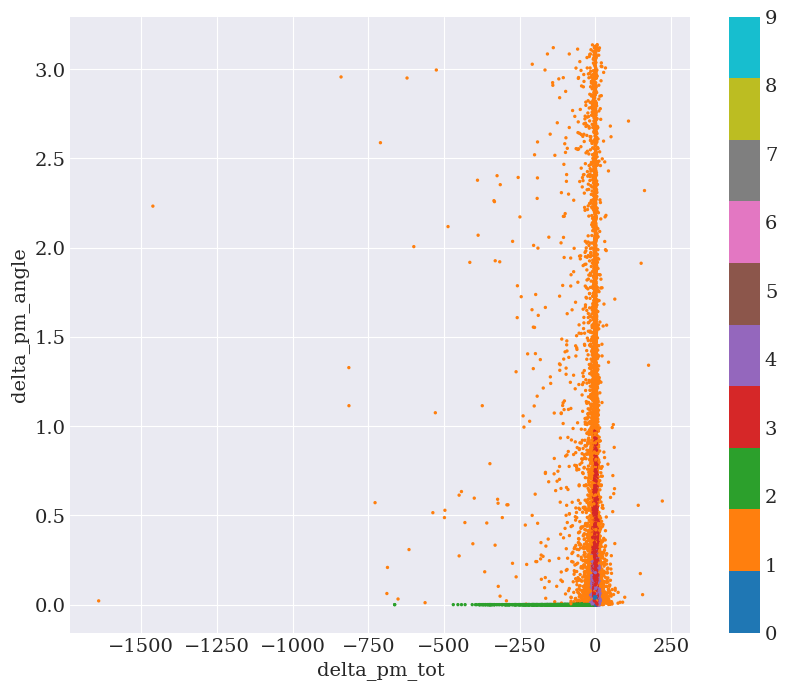

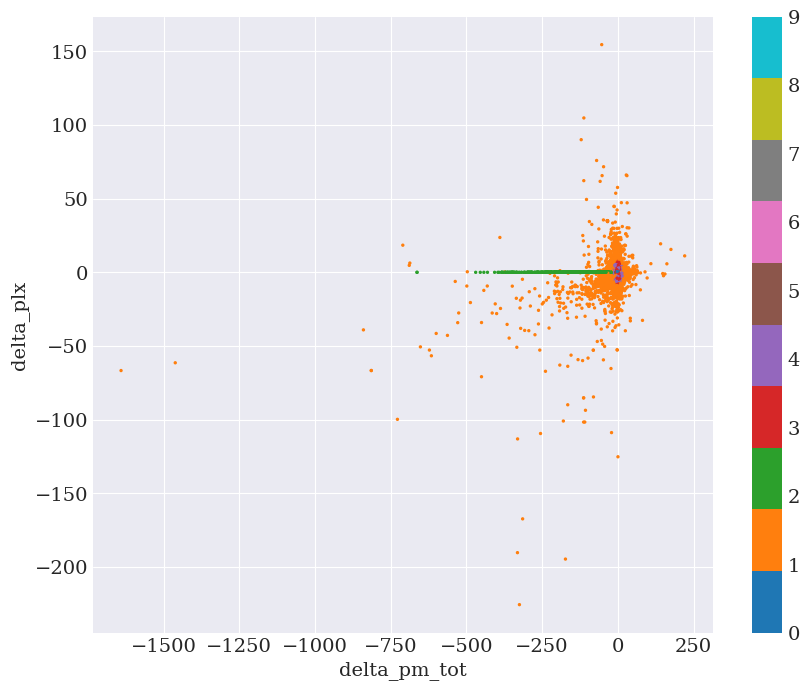

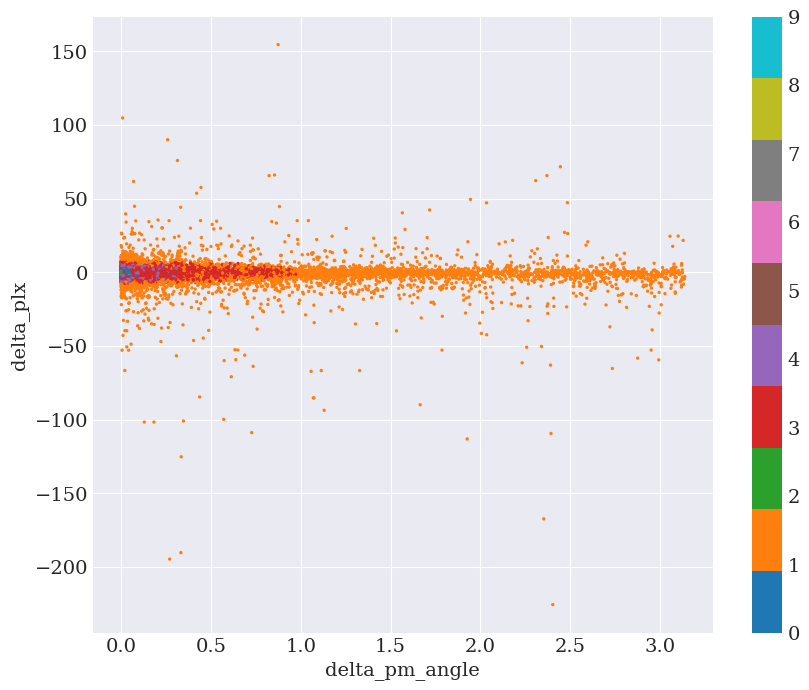

In [96]:

for i in range(len(dnames)):
    for j in range(i+1, len(dnames)):
        fig, ax = plt.subplots(1,1,figsize=(10,8))
        xname= dnames[i]
        yname = dnames[j]
        #spread = ax.scatter(tab[xname], tab[yname], c=labels, s=2, cmap='tab10')
        spread = ax.scatter(data[:,i], data[:,j], s=2, c=labels,cmap='tab10', vmin=0, vmax=9)
        ax.set_xlabel(xname)
        ax.set_ylabel(yname)
        plt.colorbar(spread)
        plt.show()

['G_Gpred', 'D', 'delta_pm_tot', 'delta_pm_angle', 'delta_plx']


(array([8.5952e+04, 1.8013e+04, 7.8860e+03, 4.3790e+03, 2.6440e+03,
        1.7220e+03, 1.2590e+03, 9.6700e+02, 6.8200e+02, 5.1500e+02,
        4.5500e+02, 3.5700e+02, 3.2400e+02, 2.6400e+02, 2.3100e+02,
        1.8200e+02, 1.8000e+02, 1.6200e+02, 1.3600e+02, 1.3700e+02,
        1.0700e+02, 8.9000e+01, 9.6000e+01, 8.7000e+01, 8.4000e+01,
        7.2000e+01, 6.6000e+01, 5.4000e+01, 7.2000e+01, 6.4000e+01,
        5.7000e+01, 4.7000e+01, 5.5000e+01, 2.8000e+01, 4.5000e+01,
        4.2000e+01, 4.0000e+01, 4.6000e+01, 4.4000e+01, 4.2000e+01,
        3.6000e+01, 4.6000e+01, 4.4000e+01, 4.4000e+01, 4.1000e+01,
        2.8000e+01, 3.5000e+01, 4.8000e+01, 2.8000e+01, 3.8000e+01]),
 array([0.        , 0.06275211, 0.12550421, 0.18825632, 0.25100842,
        0.31376053, 0.37651264, 0.43926474, 0.50201685, 0.56476895,
        0.62752106, 0.69027317, 0.75302527, 0.81577738, 0.87852949,
        0.94128159, 1.0040337 , 1.0667858 , 1.12953791, 1.19229002,
        1.25504212, 1.31779423, 1.38054633, 1.

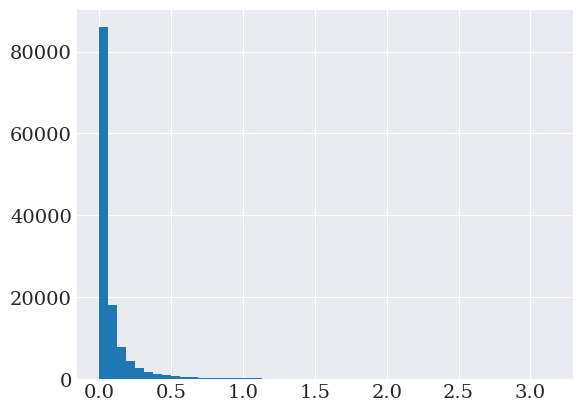

In [82]:
print(dnames)
plt.hist(data[:,3], bins=50)

In [79]:
len(data[:,3][data[:,3] < 1e-10])

3196

log G seems a little bit uninformative, and quite dominant. How do the two log g values compare?

In [16]:
# test on a 'random' crossmatch
xm = np.load('../../results/final_crossmatch+PMC+EIB_10as__best_neighbour_likeliest_position.npy')
logg_gaia, logg_hipp = get_delta_logG(xm)

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.


/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for F5. Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for B9. Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for G0. Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for M6e-M8.5e Tc. Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for G5. Assigning V.
  warnings.warn(f"Missing luminosity cla

/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for A3m. Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for G5w.... Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for K6. Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for G6/8wF8IV/V. Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:709: UserWarning: Missing subclass for Fm. Assigning 5.
  warnings.warn(f"Missing subclass for {spec

/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for B9p Si. Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for O6.5.... Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:709: UserWarning: Missing subclass for Ap SrCrEu. Assigning 5.
  warnings.warn(f"Missing subclass for {spec}. Assigning 5.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for Ap SrCrEu. Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for M4e-M9e. Assigning V.
  warnings.warn(f"Missing luminosity c

/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for K2.... Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:709: UserWarning: Missing subclass for K:p. Assigning 5.
  warnings.warn(f"Missing subclass for {spec}. Assigning 5.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for K:p. Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for K2:. Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:709: UserWarning: Missing subclass for Fp.... Assigning 5.
  warnings.warn(f"Missing subclass for {spec}. Assigning 5.")
/ho

...

/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for A0w. Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for A2 + A7. Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:671: UserWarning: Unable to match spectral type R2v.
  warnings.warn(f"Unable to match spectral type {spec}.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:709: UserWarning: Missing subclass for G:+.... Assigning 5.
  warnings.warn(f"Missing subclass for {spec}. Assigning 5.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for G:+.... Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home

/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:671: UserWarning: Unable to match spectral type S7.5v.
  warnings.warn(f"Unable to match spectral type {spec}.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for G0:II:. Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for M2  comp. Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for A2e + K0. Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:671: UserWarning: Unable to match spectral type R3v.
  warnings.warn(f"Unable to match spectral type {spec}.")
/home/re

/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:709: UserWarning: Missing subclass for G:w. Assigning 5.
  warnings.warn(f"Missing subclass for {spec}. Assigning 5.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for G:w. Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for O9p. Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for A3mA5-A7. Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for M5.5e-M8.8e. Assigning V.
  warnings.warn(f"Missing luminosity class for {

[[3.94569993]
 [4.34849977]
 [4.5       ]
 ...
 [3.96390009]
 [3.82369995]
 [3.91020012]] [4.5 4.5 4.5 ... 4.5 4.5 4.5]
(117812, 1) (117812,)


/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for K0/K1+A/F. Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for K5v.... Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for M5E-M8.5E. Assigning V.
  warnings.warn(f"Missing luminosity class for {spec}. Assigning V.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:709: UserWarning: Missing subclass for FVw. Assigning 5.
  warnings.warn(f"Missing subclass for {spec}. Assigning 5.")
/home/rens/.local/lib/python3.10/site-packages/MeanStars/MeanStars.py:718: UserWarning: Missing luminosity class for A0MNp.... Assigning V.
  warnings.warn(f"Missing luminosity clas

Text(0, 0.5, 'Hipp')

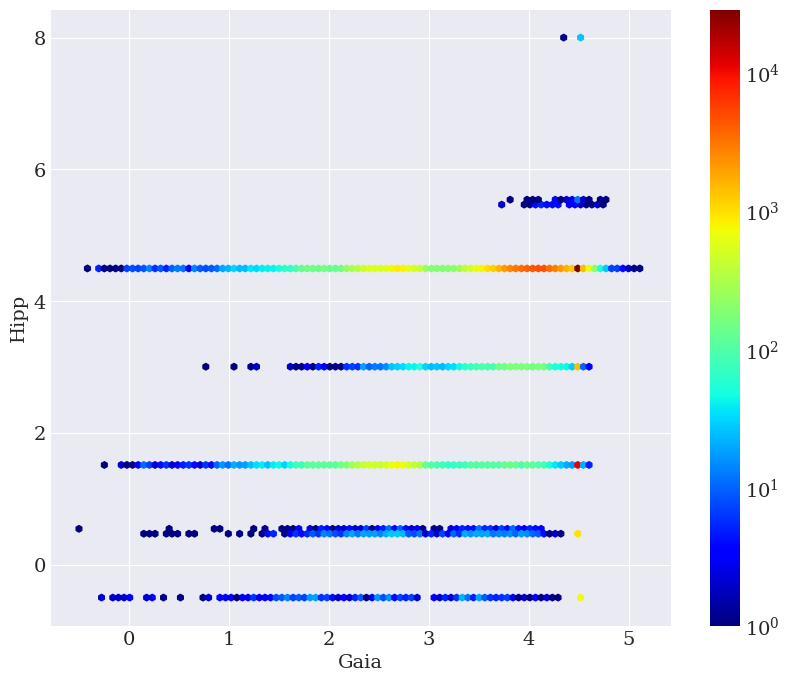

In [27]:
fig, ax = plt.subplots(1,1,figsize=(10,8))
density = ax.hexbin(logg_gaia.T, logg_hipp, mincnt=1, cmap='jet', bins='log')
plt.colorbar(density)
ax.set_xlabel('Gaia')
ax.set_ylabel('Hipp')

# Add in TDSC

In [5]:
names

['hip_id',
 'gaia source_id',
 'method',
 'G_Gpred',
 'Hp_mag',
 'G_mag',
 'Hip_BV',
 'Gaia_BpRp',
 'D',
 'distance',
 'delta_pm_alpha',
 'delta_pm_dec',
 'delta_pm_tot',
 'Delta_LogG']

In [11]:
hipid = 25085

idxs = np.where(tab['Hip_ID'] == hipid)[0]
for idx in idxs:
    d = tab[idx]
    print(d[1])
    #print(tab[idx][3:])
print(d)

4826630650350231552
4826630650350231552
4826630650350231552
(25085, 4826630650350231552, 1.0, 0.03489248856995886, 10.5891, 10.308562278747559, 0.733, 0.9584197998046875, 136.0998478433543, 503.23816267207394, 7.402932805871529, 13.887999029745032, 15.737850271827085, -0.12360000610351562)


In [12]:
all_neighbours = np.load('../../results/final_crossmatch+PMC+EIB_10as_all_neighbours.npy')

In [17]:
u, c = np.unique(all_neighbours[:,0], return_counts=True)
print(np.max(c))

6


In [13]:
all_neighbours[all_neighbours[:,0] == hipid]

array([[              25085, 4826630650350231552,             4736303]])

In [14]:
rpath = '../../results/'
pos_xm = np.load(rpath+'final_crossmatch+PMC+EIB_10as__best_neighbour_likeliest_position.npy')
mag_xm = np.load(rpath+'final_crossmatch+PMC+EIB_10as__best_neighbour_likeliest_magnitude.npy')
nea_xm = np.load(rpath+'final_crossmatch+PMC+EIB_10as_best_neighbour_nearest.npy')

xm_tabs = [pos_xm, mag_xm, nea_xm]

In [15]:
for xm in xm_tabs:
    print(xm[xm[:,0] == hipid])

[[              25085 4826630650350231552             4736303]]
[[              25085 4826630650350231552             4736303]]
[[              25085 4826630650350231552             4736303]]


In [80]:
from data_queries import gaia_login, launch_job, get_data
query = 'select hip from gaiadr3.tycho2tdsc_merge where hip is not null'
job = launch_job(query)
data = get_data(job)

INFO: Query finished. [astroquery.utils.tap.core]


In [82]:
u, c = np.unique(data['hip'], return_counts=True)
doubles = u[c>1]

In [95]:
print(len(doubles))

7379


In [98]:
no_dubs = 0
for hip in doubles:
    if all_neighbours[all_neighbours[:,0] == hip].shape[0] == 1:
        print(hip)
        no_dubs += 1
print(no_dubs)

25
53
96
174
275
306
487
603
634
673
683
743
782
871
956
1060
1068
1190
1260
1281
1336
1417
1464
1531
1621
1646
1709
1753
2143
2187
2206
2226
2278
2411
2437
2438
2487
2505
2556
2713
2726
2750
2794
2863
2886
2893
2935
2940
3159
3176
3351
3385
3513
3673
3821
3845
3851
3898
3899
3982
4049
4082
4228
4239
4267
4285
4322
4327
4451
4512
4536
4558
4755
4789
4849
4862
4870
5007
5100
5140
5165
5264
5363
5383
5399
5404
5427
5434
5443
5444
5514
5546
5562
5679
5712
5773
5829
6060
6105
6142
6334
6377
6962
7232
7264
7329
7397
7709
7751
7879
7895
8048
8115
8199
8203
8270
8313
8519
8545
8998
9126
9203
9276
9378
9434
9480
9487
9498
9621
9661
9670
9774
9822
9874
10139
10192
10332
10552
10892
10956
11004
11024
11092
11163
11178
11277
11318
11348
11474
11535
11603
11604
11620
11639
11644
11719
11731
11806
11871
11896
11918
12095
12171
12224
12279
12318
12405
12491
12504
12548
12565
12706
12717
12742
12838
12912
12986
12990
13083
13341
13432
13498
13769
13772
13892
13914
13916
13983
14132
14169
14218
14249


111626
111670
111687
111775
111903
111911
111965
111974
112139
112170
112323
112325
112346
112386
112871
112897
112915
112924
113048
113092
113184
113191
113273
113333
113352
113384
113398
113454
113488
113503
113647
113788
113792
113795
113862
113921
113999
114027
114071
114121
114123
114131
114132
114161
114215
114222
114396
114415
114473
114643
114689
114782
114853
114994
115097
115112
115177
115181
115261
115377
115402
115467
115521
115647
115666
115700
115723
115916
116024
116038
116066
116096
116104
116123
116247
116310
116425
116578
116582
116667
116716
116810
116818
116853
116920
116956
117062
117073
117340
117410
117471
117545
117554
117729
117780
117837
117919
118018
118158
118287
1598
